### 11. Επιθεώρηση του Gold Layer

Το Gold Layer είναι ο τελικός προορισμός της προεπεξεργασίας: τα δεδομένα έχουν υποστεί one-hot encoding, κανονικοποίηση και SMOTE oversampling. Το train set έχει πλέον διπλασιαστεί (~7.800 δείγματα, ισορροπημένο), ενώ το test παραμένει ανέγγιχτο (~1.000 δείγματα, φυσική κατανομή).

Το feature vector περιέχει τις αριθμητικές μεταβλητές συν τις one-hot στήλες που προκύπτουν από τις κατηγορικές. Η ακριβής αντιστοίχιση διάστασης → στήλης/κατηγορίας βρίσκεται στο `feature_metadata.json`. Παρακάτω φαίνεται η επίδραση του SMOTE στο μέγεθος του train και η δομή των τελικών feature vectors.

### 1. Φόρτωση των δεδομένων από το Silver Layer

Το Silver Layer αντιπροσωπεύει την ενδιάμεση κατάσταση των δεδομένων: οι κενές τιμές του BMI έχουν ήδη συμπληρωθεί (median imputation), οι κατηγορικές μεταβλητές έχουν αποκτήσει αριθμητικούς δείκτες, αλλά , κρίσιμα , οι αρχικές στήλες με τα string labels (`gender`, `work_type`, `smoking_status` κλπ.) εξακολουθούν να υπάρχουν. Η παράλληλη ύπαρξη indexed και original στηλών είναι σκόπιμη: οι μεν indexed τροφοδοτούν το pipeline, οι δε original επιτρέπουν σε εμάς να βλέπουμε readable ονόματα στις οπτικοποιήσεις.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import json

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

spark = SparkSession.builder \
    .appName("Stroke_EDA") \
    .master("local[*]") \
    .getOrCreate()

In [ ]:
train_silver = spark.read.parquet("../data/train_silver.parquet")
test_silver = spark.read.parquet("../data/test_silver.parquet")

print(f"Train Silver: {train_silver.count()} γραμμές, {len(train_silver.columns)} στήλες")
print(f"Test Silver:  {test_silver.count()} γραμμές, {len(test_silver.columns)} στήλες")

Train Silver: 4123 γραμμές, 16 στήλες
Test Silver:  987 γραμμές, 16 στήλες


In [ ]:
train_pdf = train_silver.toPandas()
test_pdf = test_silver.toPandas()

num_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
cat_labels = ["Φύλο", "Έγγαμος/η", "Εργασία", "Περιοχή", "Κάπνισμα"]

print(f"Train: {train_pdf.shape[0]} × {train_pdf.shape[1]}")
print(f"Test:  {test_pdf.shape[0]} × {test_pdf.shape[1]}")
print(f"\nNulls στο bmi - train: {train_pdf['bmi'].isna().sum()}, test: {test_pdf['bmi'].isna().sum()}")

Train: 4123 × 16
Test:  987 × 16

Nulls στο bmi - train: 0, test: 0


### 2. Κατανομή των κλάσεων

Στο στάδιο του Silver Layer το train set διατηρεί ακόμα το φυσικό imbalance. Από τα ~4.123 δείγματα εκπαίδευσης, μόνο περίπου 200 αντιστοιχούν σε ασθενείς με εγκεφαλικό, ποσοστό γύρω στο 5%. Αυτή η ανισορροπία είναι ο λόγος που το SMOTE εφαρμόζεται αργότερα, στο στάδιο του Gold Layer. Το test set έχει παρόμοια αναλογία, όπως είναι αναμενόμενο από έναν τυχαίο διαχωρισμό.

Το διάγραμμα δείχνει την κατανομή των δειγμάτων μεταξύ train και test και το class imbalance στο train.

In [ ]:
t0 = (train_pdf["stroke"] == 0).sum()
t1 = (train_pdf["stroke"] == 1).sum()
e0 = (test_pdf["stroke"] == 0).sum()
e1 = (test_pdf["stroke"] == 1).sum()

print(f"Train - No Stroke: {t0} | Stroke: {t1} | stroke%: {t1/(t0+t1)*100:.1f}%")
print(f"Test  - No Stroke: {e0}   | Stroke: {e1}   | stroke%: {e1/(e0+e1)*100:.1f}%")

Train - No Stroke: 3916 | Stroke: 207 | stroke%: 5.0%
Test  - No Stroke: 945   | Stroke: 42   | stroke%: 4.3%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

bars = ax1.bar(["Train", "Test"], [len(train_pdf), len(test_pdf)],
              color=["#3498db", "#95a5a6"], width=0.5, edgecolor='white')
ax1.set_title("Train / Test Split", fontsize=13, fontweight='bold')
ax1.set_ylabel("Γραμμές")
for bar, val in zip(bars, [len(train_pdf), len(test_pdf)]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
            ha='center', fontsize=12, fontweight='bold')

bars = ax2.bar(["No Stroke (0)", "Stroke (1)"], [t0, t1],
              color=["#2ecc71", "#e74c3c"], width=0.5, edgecolor='white')
ax2.set_title("Κατανομή κλάσεων στο Train", fontsize=13, fontweight='bold')
ax2.set_ylabel("Γραμμές")
for bar, val in zip(bars, [t0, t1]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Κατανομές των αριθμητικών μεταβλητών

Οι τρεις συνεχείς μεταβλητές , ηλικία, επίπεδο γλυκόζης και BMI , εξετάζονται πρώτα ως προς την κατανομή τους. Τα ιστογράμματα αποκαλύπτουν το εύρος, τη συγκέντρωση και την ασυμμετρία κάθε μεταβλητής. Η μέση τιμή (mean) και η διάμεσος (median) επισημαίνονται για άμεση σύγκριση: όταν απέχουν σημαντικά, η κατανομή είναι ασύμμετρη.

Το BMI αξίζει ιδιαίτερης προσοχής: οι κενές τιμές του έχουν ήδη συμπληρωθεί με τη διάμεσο. Η συγκέντρωση τιμών γύρω από αυτή την τιμή είναι αναμενόμενη και οφείλεται ακριβώς στο imputation , δεν πρόκειται για φυσικό φαινόμενο των δεδομένων.

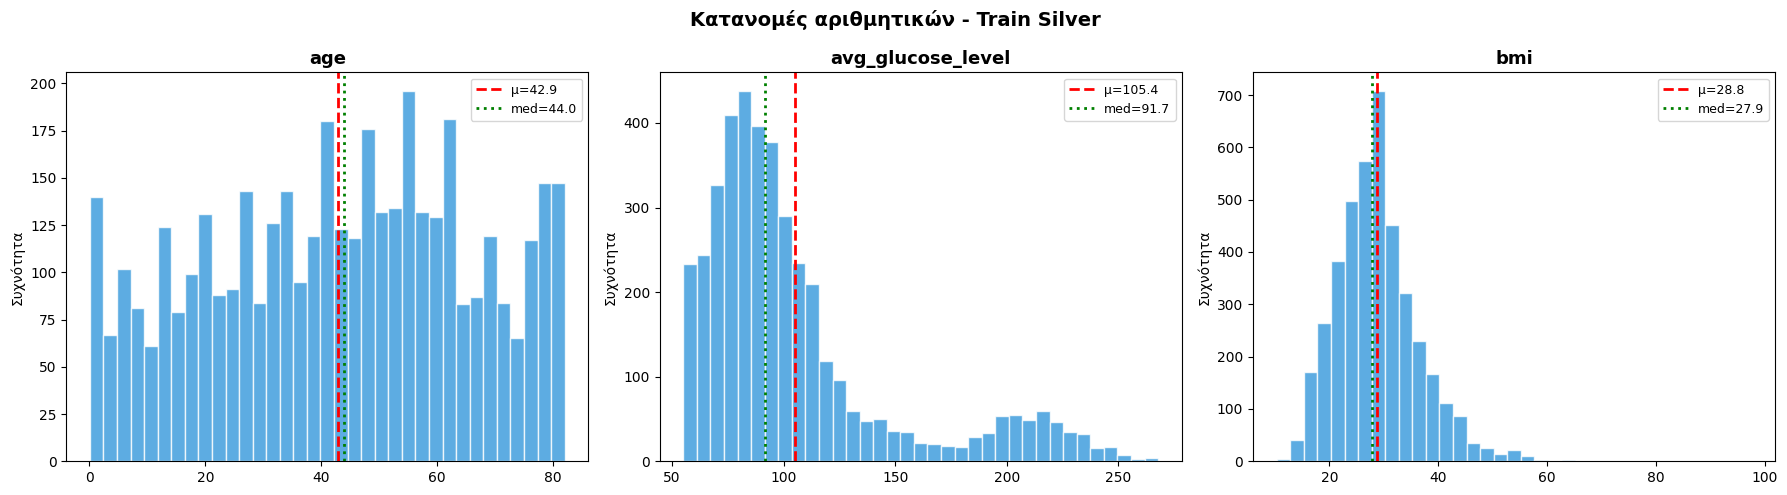

In [ ]:
plot_cols = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(plot_cols):
    data = train_pdf[col]
    ax = axes[i]
    ax.hist(data, bins=35, color="#3498db", edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel("Συχνότητα")
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'μ={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='green', linestyle=':', linewidth=2, label=f'med={np.median(data):.1f}')
    ax.legend(fontsize=9)

plt.suptitle("Κατανομές αριθμητικών - Train Silver", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Σύγκριση αριθμητικών μεταβλητών ανά κλάση stroke

Τα box plots συγκρίνουν την κατανομή κάθε αριθμητικής μεταβλητής μεταξύ ασθενών με και χωρίς εγκεφαλικό. Το πλαίσιο δείχνει το ενδοτεταρτημοριακό εύρος (IQR: 25ο–75ο εκατοστημόριο), η γραμμή στο κέντρο τη διάμεσο, και οι απομακρυσμένες γραμμές (whiskers) την έκταση των τιμών πέρα από το IQR.

Η ηλικία αναμένεται να δείξει την πιο έντονη διαφορά: οι ασθενείς με εγκεφαλικό είναι κατά μέσο όρο σημαντικά μεγαλύτεροι. Το επίπεδο γλυκόζης και το BMI εμφανίζουν ηπιότερες αλλά υπαρκτές διαφορές, υποδηλώνοντας ότι λειτουργούν ως δευτερεύοντες παράγοντες κινδύνου.

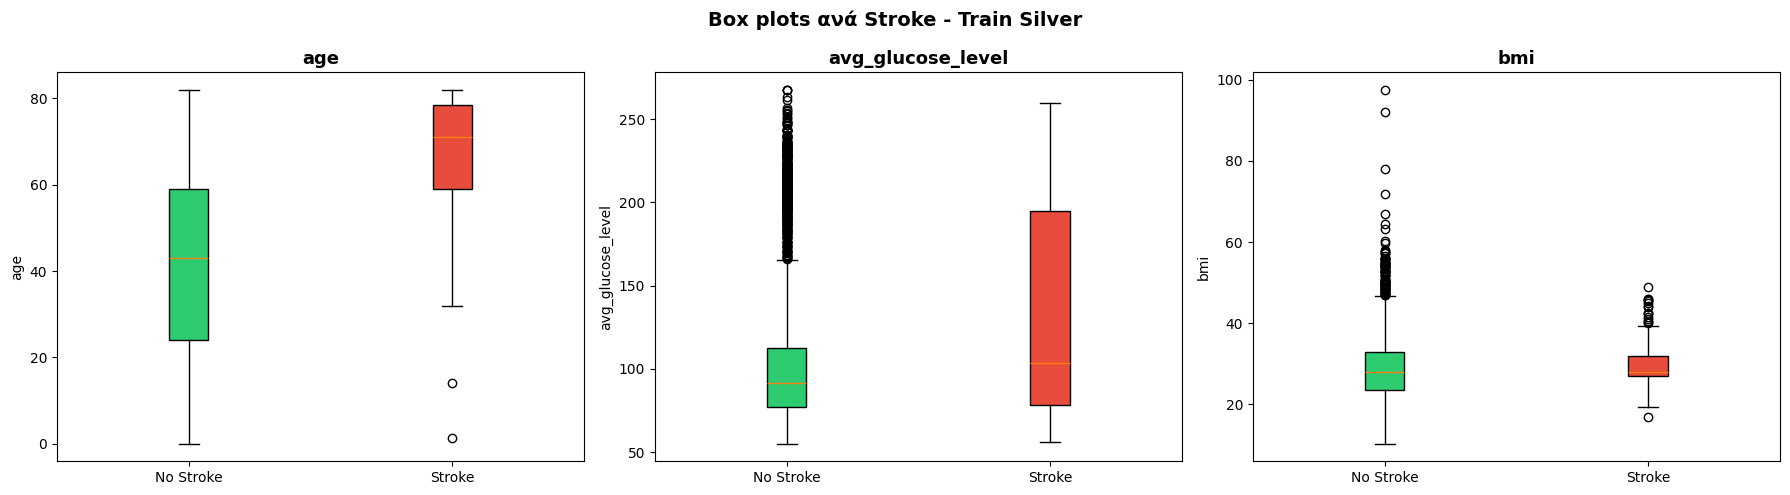

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(plot_cols):
    ax = axes[i]
    d0 = train_pdf[train_pdf["stroke"] == 0][col]
    d1 = train_pdf[train_pdf["stroke"] == 1][col]
    bp = ax.boxplot([d0, d1], patch_artist=True, tick_labels=["No Stroke", "Stroke"])
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle("Box plots ανά Stroke - Train Silver", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Κατανομές των κατηγορικών μεταβλητών

Για κάθε μία από τις πέντε κατηγορικές μεταβλητές (φύλο, οικογενειακή κατάσταση, εργασία, περιοχή κατοικίας, κάπνισμα) απεικονίζεται η συχνότητα εμφάνισης κάθε τιμής στο train set. Οι ετικέτες στους άξονες είναι τα αυθεντικά string labels , όχι αριθμοί , ώστε η ανάγνωση να είναι άμεση και κατανοητή.

Από αυτή την απεικόνιση προκύπτουν χρήσιμες παρατηρήσεις για τη σύνθεση του δείγματος: η πλειονότητα των ασθενών είναι γυναίκες, οι περισσότεροι εργάζονται στον ιδιωτικό τομέα, και η πιο συχνή κατάσταση καπνίσματος είναι το «ποτέ». Τέτοιες ανισορροπίες στις κατηγορικές μεταβλητές είναι σημαντικό να λαμβάνονται υπόψη κατά την ερμηνεία των αποτελεσμάτων της μοντελοποίησης.

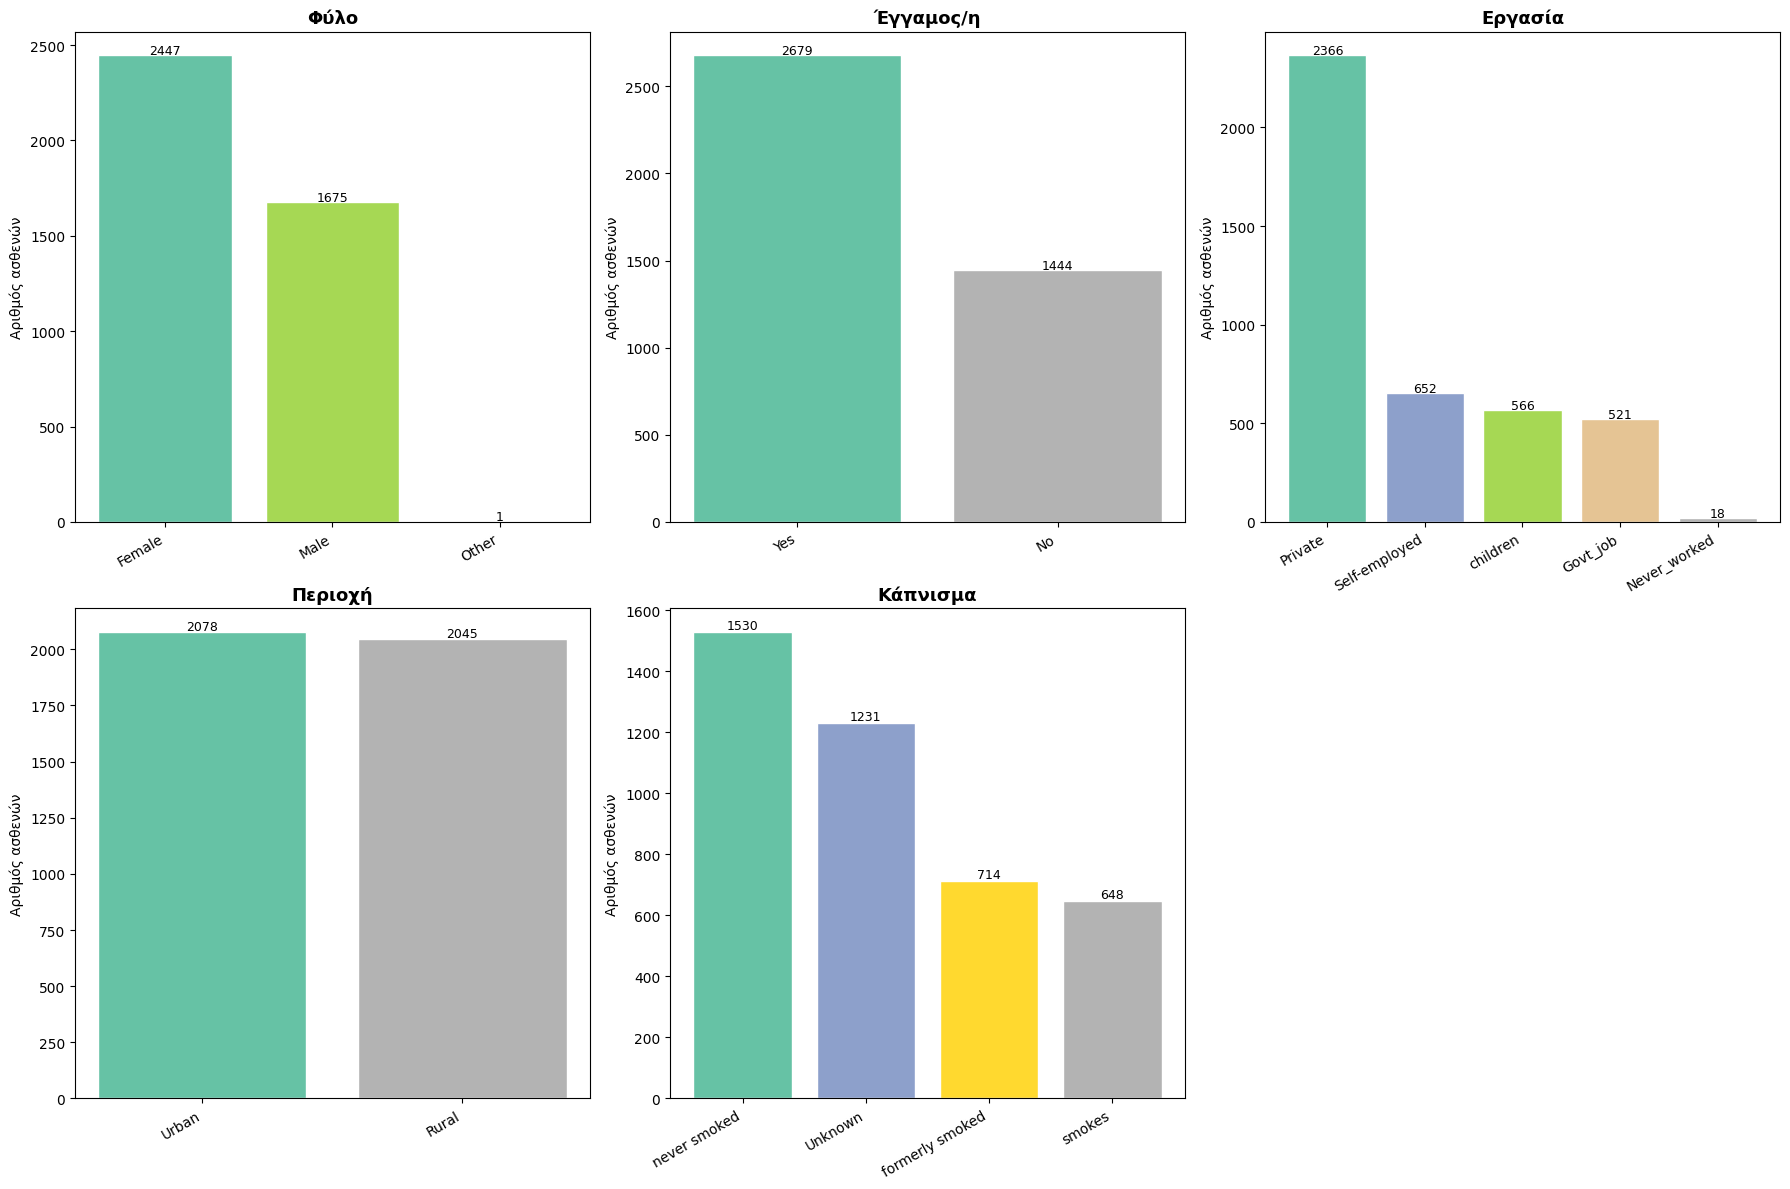

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    ax = axes[i]
    counts = train_pdf[col].value_counts()
    colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))
    bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=10)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel("Αριθμός ασθενών")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(val),
                ha='center', fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 6. Κατηγορικές μεταβλητές σε σχέση με το stroke

Εδώ εξετάζεται η πιο κρίσιμη σχέση: για κάθε κατηγορία κάθε μεταβλητής, τι ποσοστό των ασθενών έχει υποστεί εγκεφαλικό; Τα grouped bar charts δείχνουν δίπλα-δίπλα το ποσοστό stroke και no-stroke, επιτρέποντας άμεση οπτική σύγκριση.

Οι κατηγορίες με σημαντικά υψηλότερο ποσοστό stroke αναδεικνύονται ως πιθανοί παράγοντες κινδύνου. Για παράδειγμα, οι έγγαμοι, οι πρώην καπνιστές και όσοι εργάζονται στον ιδιωτικό τομέα ή είναι αυτοαπασχολούμενοι τείνουν να εμφανίζουν υψηλότερα ποσοστά , αν και η ηλικία παραμένει ο κυρίαρχος συγχυτικός παράγοντας (confounder) που πρέπει να ληφθεί υπόψη.

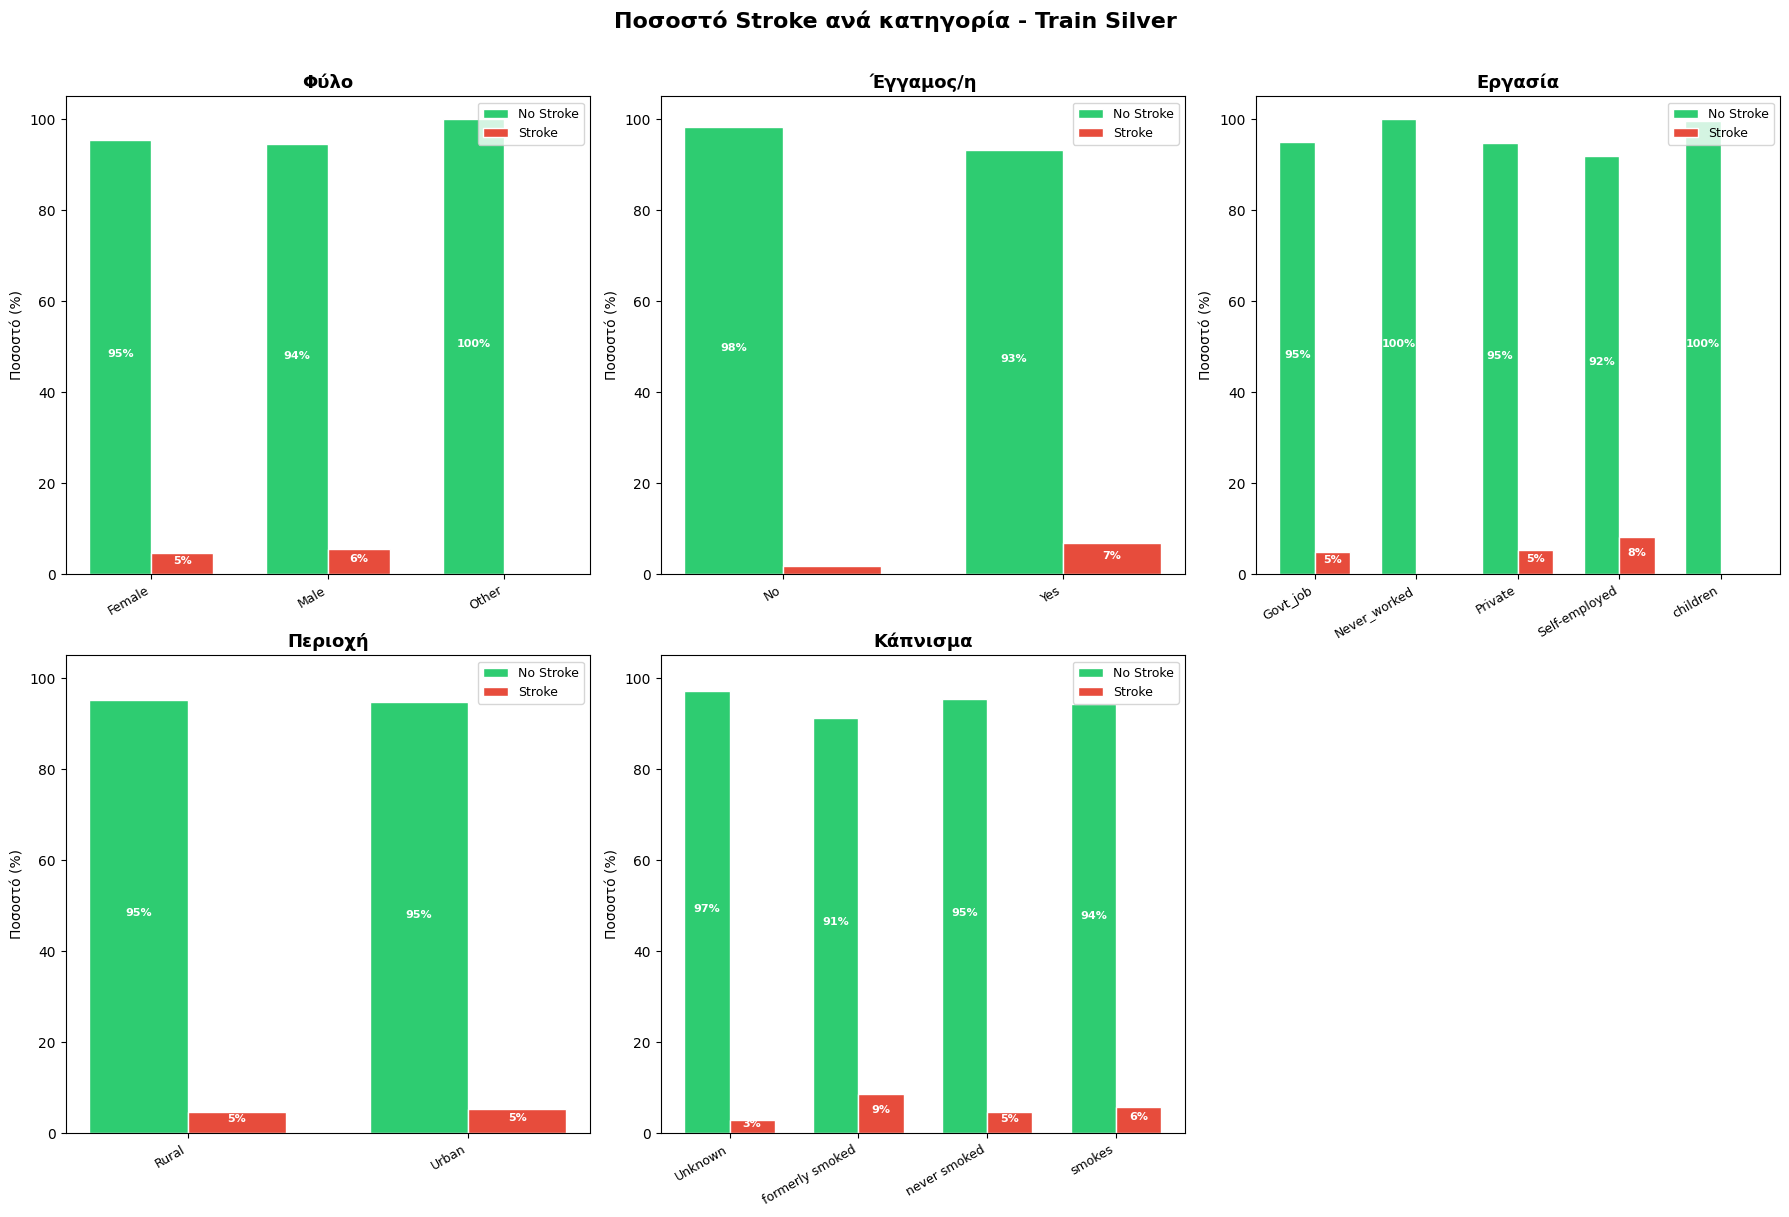

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    ax = axes[i]
    ct = pd.crosstab(train_pdf[col], train_pdf["stroke"], normalize='index') * 100

    x = np.arange(len(ct.index))
    width = 0.35

    bars0 = ax.bar(x - width/2, ct[0], width, label="No Stroke", color="#2ecc71", edgecolor='white')
    bars1 = ax.bar(x + width/2, ct[1], width, label="Stroke", color="#e74c3c", edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel("Ποσοστό (%)")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)

    for bar in bars0:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h/2, f'{h:.0f}%', ha='center', fontsize=8, color='white', fontweight='bold')
    for bar in bars1:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h/2, f'{h:.0f}%', ha='center', fontsize=8, color='white', fontweight='bold')

axes[-1].axis('off')
plt.suptitle("Ποσοστό Stroke ανά κατηγορία - Train Silver", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7. Ηλικία — ο ισχυρότερος προγνωστικός παράγοντας

Η ηλικία έχει τη μεγαλύτερη συσχέτιση με την εμφάνιση εγκεφαλικού. Το διάγραμμα πυκνότητας (density histogram) επιτρέπει τη σύγκριση των δύο κατανομών ανεξάρτητα από το μέγεθος του δείγματος , κανονικοποιεί το εμβαδόν ώστε να είναι ίσο με 1 και για τις δύο ομάδες.

Η διαφορά είναι εντυπωσιακή: η κατανομή των ασθενών χωρίς stroke κορυφώνεται γύρω στα 40–50 έτη, ενώ των ασθενών με stroke γύρω στα 70–80. Οι μέσες τιμές απέχουν περίπου 25 χρόνια. Αυτό καθιστά την ηλικία τον πιο αξιόπιστο μεμονωμένο δείκτη κινδύνου, αλλά και έναν ισχυρό συγχυτικό παράγοντα στην ανάλυση των υπόλοιπων μεταβλητών.

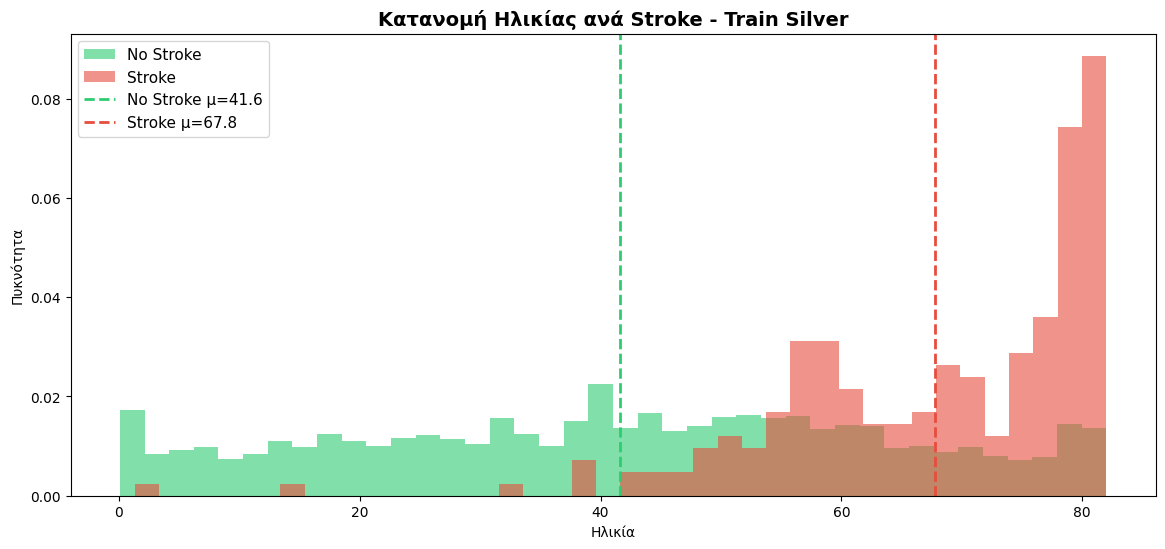

In [ ]:
ages_0 = train_pdf[train_pdf["stroke"] == 0]["age"]
ages_1 = train_pdf[train_pdf["stroke"] == 1]["age"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ages_0, bins=40, alpha=0.6, color="#2ecc71", label="No Stroke", density=True)
ax.hist(ages_1, bins=40, alpha=0.6, color="#e74c3c", label="Stroke", density=True)

ax.axvline(np.mean(ages_0), color="#2ecc71", linestyle="--", linewidth=2,
           label=f"No Stroke μ={np.mean(ages_0):.1f}")
ax.axvline(np.mean(ages_1), color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Stroke μ={np.mean(ages_1):.1f}")

ax.set_title("Κατανομή Ηλικίας ανά Stroke - Train Silver", fontsize=14, fontweight='bold')
ax.set_xlabel("Ηλικία")
ax.set_ylabel("Πυκνότητα")
ax.legend(fontsize=11)
plt.show()

### 8. Πίνακας συσχετίσεων (Correlation Matrix)

Ο πίνακας συσχετίσεων Pearson ποσοτικοποιεί τη γραμμική σχέση μεταξύ των αριθμητικών μεταβλητών και του stroke. Οι τιμές κυμαίνονται από -1 (τέλεια αρνητική συσχέτιση) έως +1 (τέλεια θετική συσχέτιση).

Ο θερμικός χάρτης αποκαλύπτει ποιες μεταβλητές σχετίζονται περισσότερο με το stroke, αλλά και ποιες σχετίζονται μεταξύ τους , υψηλή συσχέτιση μεταξύ δύο χαρακτηριστικών (π.χ. ηλικία και υπέρταση) μπορεί να υποδηλώνει πλεονασμό πληροφορίας. Το πάνω τρίγωνο αποκρύπτεται καθώς είναι συμμετρικό.

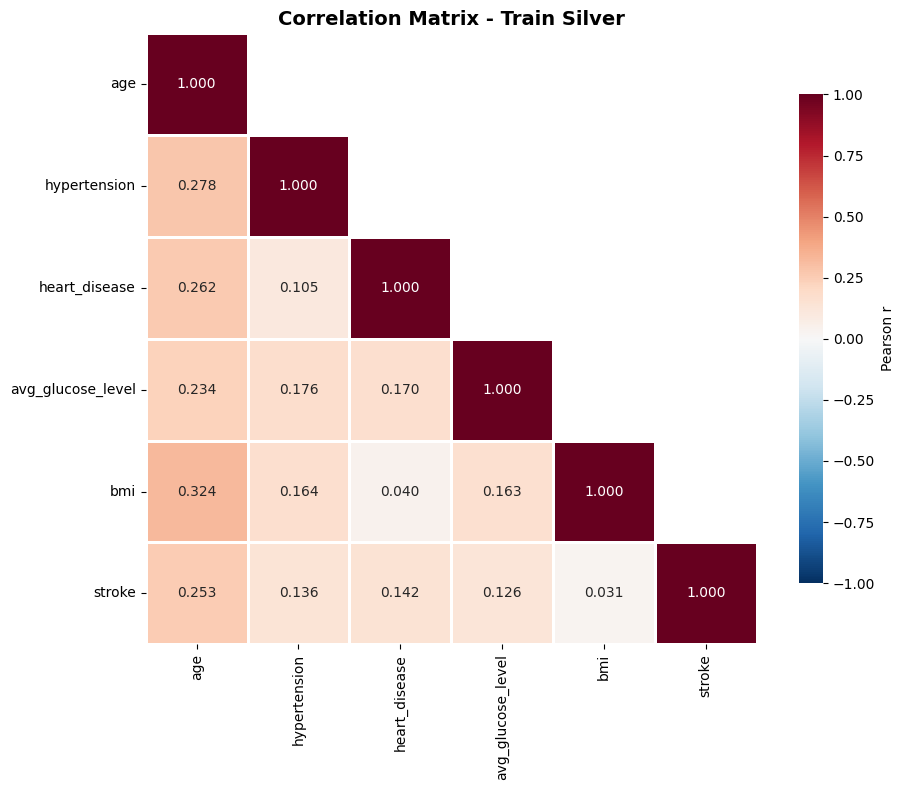

In [ ]:
corr_cols_sel = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
corr_data = train_pdf[corr_cols_sel].corr()

mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title("Correlation Matrix - Train Silver", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9. Σχέσεις μεταξύ των βασικών μεταβλητών (Pairplot)

Το pairplot προσφέρει μια πανοραμική άποψη των σχέσεων μεταξύ των τριών βασικών συνεχών μεταβλητών: ηλικίας, γλυκόζης και BMI. Στη διαγώνιο εμφανίζονται οι κατανομές (ιστογράμματα), ενώ στα υπόλοιπα κελιά τα διαγράμματα διασποράς (scatter plots) με χρωματική διαφοροποίηση ανά κλάση stroke.

Η επικάλυψη των δύο χρωμάτων σε μια περιοχή υποδηλώνει ότι οι δύο κλάσεις δεν διαχωρίζονται εύκολα σε εκείνες τις διαστάσεις. Αντίθετα, περιοχές όπου κυριαρχεί το ένα χρώμα υποδεικνύουν καλύτερη διαχωρισιμότητα. Το γράφημα χρησιμοποιεί μόνο το κάτω τρίγωνο (corner plot) για αποφυγή πλεονασμού.

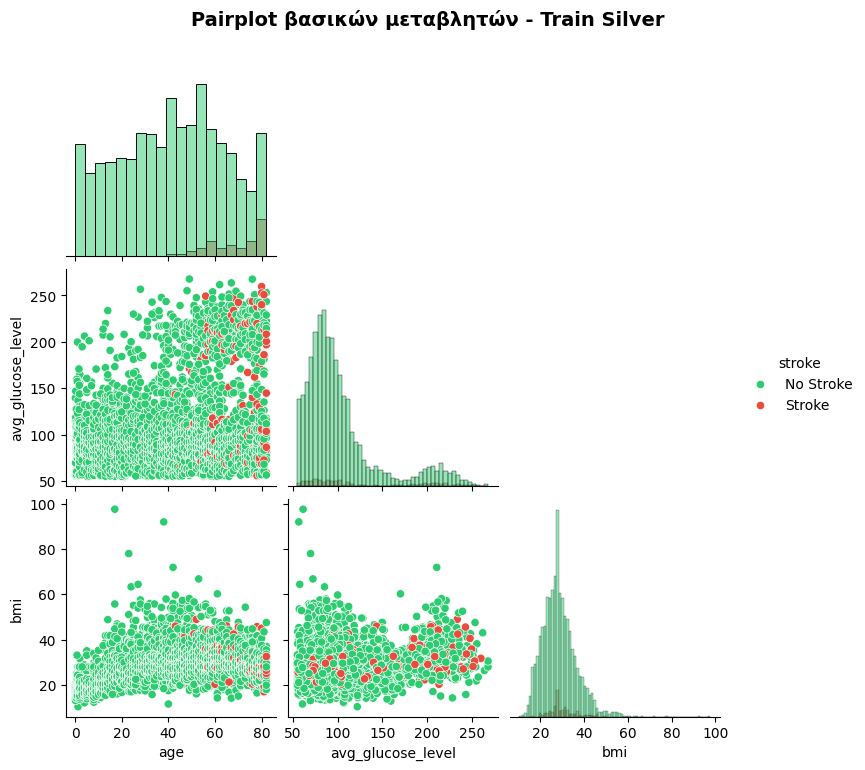

In [ ]:
pair_data = train_pdf[["age", "avg_glucose_level", "bmi", "stroke"]].copy()
pair_data["stroke"] = pair_data["stroke"].map({0: "No Stroke", 1: "Stroke"})

g = sns.pairplot(pair_data, hue="stroke",
                 palette={"No Stroke": "#2ecc71", "Stroke": "#e74c3c"},
                 diag_kind="hist", corner=True, height=2.5)
g.fig.suptitle("Pairplot βασικών μεταβλητών - Train Silver", fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 10. Ανάλυση του BMI

Το BMI αξίζει ξεχωριστής ανάλυσης για δύο λόγους: πρώτον, ήταν η μόνη μεταβλητή με ελλιπείς τιμές (3.9% πριν το imputation), και δεύτερον, η σχέση του με το εγκεφαλικό είναι πιο λεπτή από ό,τι της ηλικίας.

Το ιστόγραμμα πυκνότητας δείχνει ότι οι δύο κατανομές (stroke vs no-stroke) αλληλοεπικαλύπτονται σε μεγάλο βαθμό , το BMI από μόνο του δεν διαχωρίζει τις κλάσεις. Ωστόσο, η μέση τιμή του BMI είναι ελαφρώς υψηλότερη στους ασθενείς με stroke, και το box plot επιβεβαιώνει μια μικρή αλλά συστηματική μετατόπιση. Σε συνδυασμό με άλλους παράγοντες (ηλικία, υπέρταση), το BMI αποκτά προγνωστική αξία.

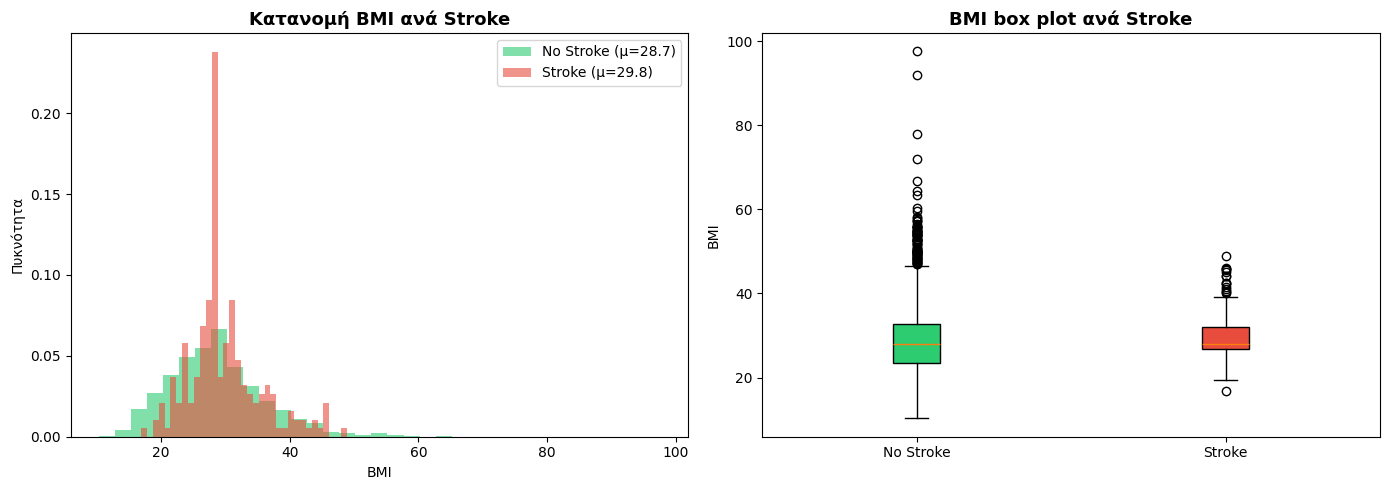

In [ ]:
bmi_0 = train_pdf[train_pdf["stroke"] == 0]["bmi"]
bmi_1 = train_pdf[train_pdf["stroke"] == 1]["bmi"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(bmi_0, bins=35, alpha=0.6, color="#2ecc71", label=f"No Stroke (μ={bmi_0.mean():.1f})", density=True)
ax1.hist(bmi_1, bins=35, alpha=0.6, color="#e74c3c", label=f"Stroke (μ={bmi_1.mean():.1f})", density=True)
ax1.set_title("Κατανομή BMI ανά Stroke", fontsize=13, fontweight='bold')
ax1.set_xlabel("BMI")
ax1.set_ylabel("Πυκνότητα")
ax1.legend()

bp = ax2.boxplot([bmi_0, bmi_1], patch_artist=True, tick_labels=["No Stroke", "Stroke"])
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax2.set_title("BMI box plot ανά Stroke", fontsize=13, fontweight='bold')
ax2.set_ylabel("BMI")

plt.tight_layout()
plt.show()

### 11. Επιθεώρηση του Gold Layer

Το Gold Layer είναι ο τελικός προορισμός της προεπεξεργασίας: τα δεδομένα έχουν υποστεί one-hot encoding, κανονικοποίηση και SMOTE oversampling. Το train set έχει πλέον διπλασιαστεί (~7.800 δείγματα, ισορροπημένο), ενώ το test παραμένει ανέγγιχτο (~1.000 δείγματα, φυσική κατανομή).

Το feature vector περιέχει τις αριθμητικές μεταβλητές συν τις one-hot στήλες που προκύπτουν από τις κατηγορικές. Η ακριβής αντιστοίχιση διάστασης → στήλης/κατηγορίας βρίσκεται στο `feature_metadata.json`. Παρακάτω φαίνεται η επίδραση του SMOTE στο μέγεθος του train και η δομή των τελικών feature vectors.

In [ ]:
train_gold = spark.read.parquet("../data/train_gold.parquet")
test_gold = spark.read.parquet("../data/test_gold.parquet")

feat_dim = train_gold.select("features").first()[0].size

print(f"Train Gold: {train_gold.count()} δείγματα")
print(f"Test Gold:  {test_gold.count()} δείγματα")
print(f"Διάσταση feature vectors: {feat_dim}")

Train Gold: 7832 δείγματα
Test Gold:  987 δείγματα
Διάσταση feature vectors: 21


In [ ]:
# Φόρτωση feature metadata για επίγνωση των διαστάσεων
with open("../data/feature_metadata.json", "r", encoding="utf-8") as f:
    feature_meta = json.load(f)

feat_names = []
for feat in feature_meta["features"]:
    if feat["type"] == "onehot":
        feat_names.append(f"{feat['column']}_{feat['category']}")
    else:
        feat_names.append(feat["column"])

print(f"Φορτώθηκαν {len(feat_names)} ονόματα χαρακτηριστικών")

In [ ]:
gold_labels = np.array(train_gold.select("stroke").rdd.map(lambda r: r[0]).collect())
g0 = (gold_labels == 0).sum()
g1 = (gold_labels == 1).sum()
gold_count = len(gold_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

bars = ax1.bar(["Silver (Train)", "Gold (Train)"], [len(train_pdf), gold_count],
              color=["#95a5a6", "#9b59b6"], width=0.5, edgecolor='white')
ax1.set_title("Μέγεθος Train Set πριν/μετά το SMOTE", fontsize=13, fontweight='bold')
ax1.set_ylabel("Γραμμές")
for bar, val in zip(bars, [len(train_pdf), gold_count]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40, str(val),
            ha='center', fontsize=12, fontweight='bold')

bars = ax2.bar(["No Stroke", "Stroke"], [g0, g1],
              color=["#2ecc71", "#e74c3c"], width=0.5, edgecolor='white')
ax2.set_title("Ισορροπημένο Train (Gold Layer)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Γραμμές")
for bar, val in zip(bars, [g0, g1]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
sample = np.array(train_gold.limit(100).select("features").rdd.map(lambda r: r[0].toArray()).collect())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(sample[:, :10], aspect='auto', cmap='viridis')
axes[0].set_title("Πρώτες 10 διαστάσεις (100 samples)", fontsize=12, fontweight='bold')
axes[0].set_xticks(range(min(10, len(feat_names))))
axes[0].set_xticklabels(feat_names[:10], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("Δείγμα")
plt.colorbar(im, ax=axes[0], shrink=0.6)

axes[1].hist(sample[:, 0], bins=20, color="#3498db", edgecolor='white', alpha=0.8)
axes[1].set_title(f"Κατανομή: {feat_names[0]}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Τιμή")
axes[1].set_ylabel("Συχνότητα")

plt.tight_layout()
plt.show()

### 12. Συμπεράσματα και επόμενα βήματα

Τα ευρήματα της διερευνητικής ανάλυσης συνοψίζονται και καθοδηγούν τις επιλογές μοντελοποίησης που ακολουθούν.

**1. Class imbalance:** Μόλις το 5% του train set έχει υποστεί εγκεφαλικό. Το SMOTE εφαρμόζεται αργότερα στο Gold Layer για να δημιουργηθεί ισορροπημένο σύνολο με 3.916 δείγματα ανά κλάση. Το test παραμένει με τη φυσική του αναλογία για ρεαλιστική αξιολόγηση.

**2. Ηλικία:** Ο ισχυρότερος προγνωστικός παράγοντας. Η μέση ηλικία των ασθενών με εγκεφαλικό είναι ~68 έτη έναντι ~42 για τους υπόλοιπους — διαφορά που ξεπερνά τα 25 έτη. Ωστόσο, λειτουργεί και ως confounder στην ανάλυση των υπόλοιπων μεταβλητών.

**3. BMI:** Μετά το imputation με τη διάμεσο (~28), η κατανομή είναι πλήρης. Το BMI από μόνο του δεν διαχωρίζει τις κλάσεις, αλλά σε συνδυασμό με άλλους παράγοντες αποκτά προγνωστική αξία. Οι ασθενείς με εγκεφαλικό έχουν ελαφρώς υψηλότερο BMI.

**4. Υπέρταση & καρδιοπάθεια:** Οι δύο αυτές δυαδικές μεταβλητές είναι σαφείς παράγοντες κινδύνου. Οι ασθενείς με υπέρταση ή με καρδιοπάθεια εμφανίζουν σημαντικά υψηλότερα ποσοστά εγκεφαλικού.

**5. Κάπνισμα:** Οι πρώην καπνιστές εμφανίζουν υψηλότερο ποσοστό stroke από όσους δεν κάπνισαν ποτέ ή καπνίζουν τώρα. Η σχέση καπνίσματος-εγκεφαλικού δεν είναι γραμμική.

**6. Γλυκόζη:** Τα υψηλά επίπεδα γλυκόζης σχετίζονται με αυξημένο κίνδυνο. Το scatter plot του pairplot δείχνει ότι τιμές άνω του 200 εμφανίζονται σχεδόν αποκλειστικά σε ασθενείς με εγκεφαλικό.

**7. Silver Layer:** 16 στήλες με readable labels, 4.123 δείγματα στο train και 987 στο test.

**8. Gold Layer:** Το feature vector περιέχει τις αριθμητικές μεταβλητές και τις one-hot στήλες ως sparse vectors. Η ακριβής αντιστοίχιση βρίσκεται στο `feature_metadata.json`. Το train έχει ισορροπήσει σε 7.832 δείγματα μετά το SMOTENC, 3.916 ανά κλάση.

**Επόμενο βήμα:** Δεδομένου του strong class imbalance και του ότι κάποιες σχέσεις δεν είναι γραμμικές, η μοντελοποίηση θα ξεκινήσει με απλά μοντέλα (λογιστική παλινδρόμηση) και θα προχωρήσει σε πιο σύνθετα (τυχαία δάση, δέντρα ενίσχυσης) για να συλλάβει τις μη-γραμμικές αλληλεπιδράσεις. Το Gold Layer με τα ισορροπημένα δεδομένα θα είναι η είσοδος για τη μοντελοποίηση, ενώ το test set θα παραμείνει ανέγγιχτο μέχρι την τελική αξιολόγηση.